# Step-by-step Sentinel-2 extraction — raw pure functions

This notebook reproduces the pipeline from `step_by_step.ipynb`, but **without any YAML config files, Hydra, or `ExtractionJob.load_from_config`**. Every object is built by calling the underlying Python functions and constructors with plain parameters.

Pipeline stages:
1. **`ExtractionJob`** — build the job model directly in Python
2. **`search_stac`** — discover STAC assets
3. **`build_grouped_tasks`** — group assets into extraction tasks
4. **`read_odc_stac`** — load raw data in native CRS
5. **`reproject_odc`** — warp data to patch geoboxes
6. **`write_geotiff`** — write GeoTIFF artifacts

We also show how to run a single task with `run_task` and how to execute many tasks in parallel with `LocalExecutor`.


In [1]:
from datetime import datetime, timezone
from shapely.geometry import Polygon

from aereo.pipeline import ExtractionJob
from aereo.interfaces import ExtractConfig, GridConfig, PatchConfig
from aereo.builtins import read_odc_stac, reproject_odc, write_geotiff

# AOI polygon — Chocón reservoir, Argentina (inlined so the notebook has no file dependencies).
aoi_polygon = Polygon(
    [
        (-68.90986824592407, -39.23705421799603),
        (-68.65925870907353, -39.23705421799603),
        (-68.65925870907353, -39.41589522092947),
        (-68.90986824592407, -39.41589522092947),
        (-68.90986824592407, -39.23705421799603),
    ]
)

# Build the same job model that step_by_step.ipynb loads from config/job_sentinel2.yaml,
# but using only Python parameters.
job = ExtractionJob(
    name="sentinel2_sample",
    grid_config=GridConfig(
        target_grid_dist=10_000,
        target_grid_overlap=False,
        grid_filter_mode="intersection",
        min_coverage=0.0,
    ),
    patch_config=PatchConfig(
        resolution=10.0,
        padding=0,
        margin=10.0,
        conform_to=None,
    ),
    output_uri="/tmp/aereo_extraction",
    extract=ExtractConfig(
        read=read_odc_stac,
        preprocess=[],
        reproject=reproject_odc,
        postprocess=[],
        write=write_geotiff,
    ),
    target_aoi=aoi_polygon,
)

print("Job name:", job.name)
print("Grid config:", job.grid_config)
print("Patch config:", job.patch_config)
print("Output URI:", job.output_uri)
print("Reader callable:", job.extract.read.__name__)
print("Reprojector callable:", job.extract.reproject.__name__)
print("Writer callable:", job.extract.write.__name__)
print("Target AOI bounds:", job.effective_target_aoi.bounds)

Job name: sentinel2_sample
Grid config: target_grid_dist=10000 target_grid_overlap=False grid_filter_mode='intersection' min_coverage=0.0
Patch config: resolution=10.0 padding=0 margin=10.0 conform_to=None
Output URI: /tmp/aereo_extraction
Reader callable: read_odc_stac
Reprojector callable: reproject_odc
Writer callable: write_geotiff
Target AOI bounds: (-68.90986824592407, -39.41589522092947, -68.65925870907353, -39.23705421799603)


## Step 1 — Search: `search_stac`

The search provider queries the STAC API and returns a GeoDataFrame of matched assets. Each row corresponds to one requested asset (e.g. `red`, `nir`) from one STAC item. All parameters are passed explicitly.


In [2]:
from aereo.builtins.search import search_stac

assets = search_stac(
    stac_api_url="https://earth-search.aws.element84.com/v1",
    collections={"sentinel-2-l2a": ["red", "nir"]},
    intersects=aoi_polygon,
    start_datetime=datetime(2024, 1, 1, tzinfo=timezone.utc),
    end_datetime=datetime(2024, 1, 10, tzinfo=timezone.utc),
)

print(f"\u2713 Found {len(assets)} asset rows")
print("Columns:", list(assets.columns))
print("First rows:")
assets[["id", "collection", "channel_id", "crs", "href"]].head()

✓ Found 12 asset rows
Columns: ['id', 'collection', 'geometry', 'start_time', 'end_time', 'href', 'channel_id', 'crs', 'stac_item']
First rows:


,id,collection,channel_id,crs,href
0,S2A_19HDS_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
1,S2A_19HDS_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
2,S2A_19HES_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
3,S2A_19HES_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
4,S2B_19HDS_20240105_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...


## Step 2 — Build tasks: `build_grouped_tasks`

The task builder takes the search-result GeoDataFrame and the `ExtractionJob` and produces a list of `ExtractionTask` objects. Tasks are grouped by start time and native CRS, and patches are chunked by `cells_per_task`.


In [3]:
from aereo.builtins.task_builder import build_grouped_tasks

tasks = build_grouped_tasks(
    search_results=assets,
    job=job,
    cells_per_task=50,
)

print(f"\u2713 Built {len(tasks)} extraction task(s)")
for i, task in enumerate(tasks):
    print(f"Task {i}: {task}")

✓ Built 6 extraction task(s)
Task 0: ExtractionTask(n_assets=2, extract_len=3, patches=ExtractionPatch('ExtractionPatch(id='439D_593L', d=10000, cell_geometry=<POLYGON ((-68.837 -39.431, -68.837 -39.341, -68.953 -39.341, -68.953 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='439D_592L', d=10000, cell_geometry=<POLYGON ((-68.721 -39.431, -68.721 -39.341, -68.837 -39.341, -68.837 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='439D_591L', d=10000, cell_geometry=<POLYGON ((-68.605 -39.431, -68.605 -39.341, -68.721 -39.341, -68.721 -39.43...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='438D_594L', d=10000, cell_geometry=<POLYGON ((-68.865 -39.341, -68.865 -39.251, -68.981 -39.251, -68.981 -39.34...>, resolution=10.0, margin=10.0, padding=0, conform_to=None), ExtractionPatch(id='438D_593L', d=10000, cell_geometry=<POLYGON ((-68.748 -39.341, -68.748 -39.251, -68.865 -39.

In [4]:
# Inspect the first task in detail
task = tasks[0]

print("Task context:", dict(task.task_context))
print(f"Number of asset rows in task: {len(task.assets)}")
print(f"Number of patches in task: {len(task.patches)}")

patch = task.patches[0]
print(f"First patch id: {patch.id}")
print(f"Patch resolution: {patch.resolution} m")
print(f"Patch UTM CRS: {patch.utm_crs}")
print(f"Patch geobox shape: {patch.geobox.shape}")

# Extraction stages available on the task (delegated from job.extract)
print("Extraction stages:")
print("  read:", task.extract.read.__name__)
print(
    "  preprocess:", [getattr(p, "__name__", str(p)) for p in task.extract.preprocess]
)
print("  reproject:", task.extract.reproject.__name__)
print(
    "  postprocess:", [getattr(p, "__name__", str(p)) for p in task.extract.postprocess]
)
print("  write:", task.extract.write.__name__)

Task context: {'job_id': 'sentinel2_sample', 'chunk_id': 0, 'total_chunks': 6, 'start_time': '2024-01-02 14:33:47.691000', 'crs': 'EPSG:32719', 'init_params': {}}
Number of asset rows in task: 2
Number of patches in task: 10
First patch id: 439D_593L
Patch resolution: 10.0 m
Patch UTM CRS: 32719
Patch geobox shape: Shape2d(x=1100, y=1100)
Extraction stages:
  read: read_odc_stac
  preprocess: []
  reproject: reproject_odc
  postprocess: []
  write: write_geotiff


## Step 3 — Read: `read_odc_stac`

The reader reconstructs `pystac.Item` objects from the `stac_item` column and uses `odc.stac.load` to build a lazy `xarray.Dataset` in the native CRS of the STAC items.


In [5]:
from aereo.builtins.read import read_odc_stac

# Call the reader directly with the task.
ds_native = read_odc_stac(task)

print("Native dataset:")
print(ds_native)
print("Dataset attributes:")
print(ds_native.attrs)

Native dataset:
<xarray.Dataset> Size: 17MB
Dimensions:      (y: 1991, x: 2166, time: 1)
Coordinates:
  * y            (y) float64 16kB 5.657e+06 5.657e+06 ... 5.637e+06 5.637e+06
  * x            (x) float64 17kB 5.078e+05 5.078e+05 ... 5.294e+05 5.294e+05
  * time         (time) datetime64[us] 8B 2024-01-02T14:33:47.691000
    spatial_ref  int32 4B 32719
Data variables:
    nir          (time, y, x) uint16 9MB dask.array<chunksize=(1, 1991, 2166), meta=np.ndarray>
    red          (time, y, x) uint16 9MB dask.array<chunksize=(1, 1991, 2166), meta=np.ndarray>
Attributes:
    start_time:  2024-01-02 14:33:47.691000
    end_time:    2024-01-02 14:33:47.691000
Dataset attributes:
{'start_time': datetime.datetime(2024, 1, 2, 14, 33, 47, 691000), 'end_time': datetime.datetime(2024, 1, 2, 14, 33, 47, 691000)}


In [6]:
ds_native

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 1991, x: 2166, time: 1)
Coordinates:
  * y            (y) float64 16kB 5.657e+06 5.657e+06 ... 5.637e+06 5.637e+06
  * x            (x) float64 17kB 5.078e+05 5.078e+05 ... 5.294e+05 5.294e+05
  * time         (time) datetime64[us] 8B 2024-01-02T14:33:47.691000
    spatial_ref  int32 4B 32719
Data variables:
    nir          (time, y, x) uint16 9MB dask.array<chunksize=(1, 1991, 2166), meta=np.ndarray>
    red          (time, y, x) uint16 9MB dask.array<chunksize=(1, 1991, 2166), meta=np.ndarray>
Attributes:
    start_time:  2024-01-02 14:33:47.691000
    end_time:    2024-01-02 14:33:47.691000

## Step 4 — Reproject: `reproject_odc`

The reprojector warps the native CRS dataset onto each patch's UTM GeoBox. It returns a mapping from `patch.id` to a reprojected `xr.Dataset`.


In [7]:
from aereo.builtins.reproject import reproject_odc

# Call the reprojector directly with explicit parameters.
ds_per_patch = reproject_odc(
    ds=ds_native,
    task=task,
    resampling="nearest",
)

print(f"\u2713 Reprojected dataset available for {len(ds_per_patch)} patch(es)")
print("Patch IDs:", list(ds_per_patch.keys()))

✓ Reprojected dataset available for 10 patch(es)
Patch IDs: ['439D_593L', '439D_592L', '439D_591L', '438D_594L', '438D_593L', '438D_592L', '437D_595L', '437D_594L', '437D_593L', '437D_592L']


## Step 5 — Write: `write_geotiff`

The writer serialises a patch's dataset to a GeoTIFF and returns a GeoDataFrame of written artifacts conforming to `ArtifactSchema`.


In [8]:
from aereo.builtins.write import write_geotiff

# Write a single patch
patch = task.patches[0]
patch_artifacts = write_geotiff(
    ds=ds_per_patch[patch.id],
    task=task,
    patch=patch,
)

print(f"\u2713 Wrote {len(patch_artifacts)} artifact row(s)")
print("Columns:", list(patch_artifacts.columns))
print("Artifact rows:")
patch_artifacts[["id", "uri", "grid_cell", "start_time", "end_time"]]

✓ Wrote 1 artifact row(s)
Columns: ['id', 'source_ids', 'start_time', 'end_time', 'uri', 'collection', 'geometry', 'grid_cell', 'grid_dist', 'cell_geometry', 'cell_utm_crs', 'cell_utm_footprint']
Artifact rows:


,id,uri,grid_cell,start_time,end_time
0,439D_593L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,2024-01-02 14:33:47.691,2024-01-02 14:33:47.691


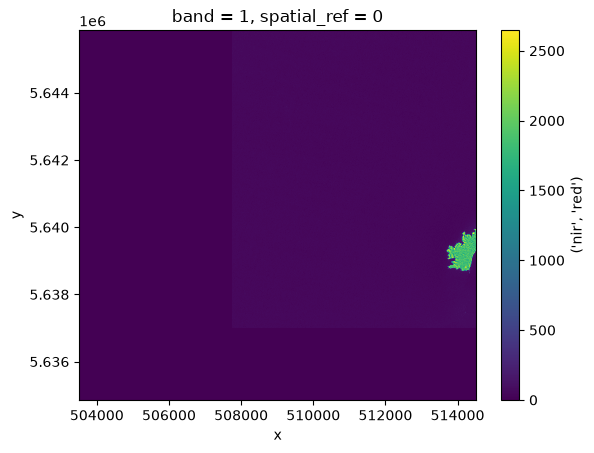

In [9]:
import rioxarray

rioxarray.open_rasterio(patch_artifacts.iloc[0].uri)[0].plot()

## Putting it together: `run_task`

`run_task(task)` executes the read → preprocess → reproject → postprocess → write loop for a single `ExtractionTask`. It is what `LocalExecutor` uses under the hood.


In [10]:
from aereo.execution import run_task

artifacts_gdf = run_task(task)

print(f"\u2713 Single task produced {len(artifacts_gdf)} artifact row(s)")
artifacts_gdf[["id", "uri", "grid_cell", "geometry"]].head()

✓ Single task produced 10 artifact row(s)


,id,uri,grid_cell,geometry
0,439D_593L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,"POLYGON ((514510 5634860, 514510 5645860, 5035..."
1,439D_592L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_592L,"POLYGON ((524530 5634840, 524530 5645840, 5135..."
2,439D_591L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_591L,"POLYGON ((534540 5634810, 534540 5645810, 5235..."
3,438D_594L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_594L,"POLYGON ((512180 5644830, 512180 5655830, 5011..."
4,438D_593L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_593L,"POLYGON ((522190 5644810, 522190 5655810, 5111..."


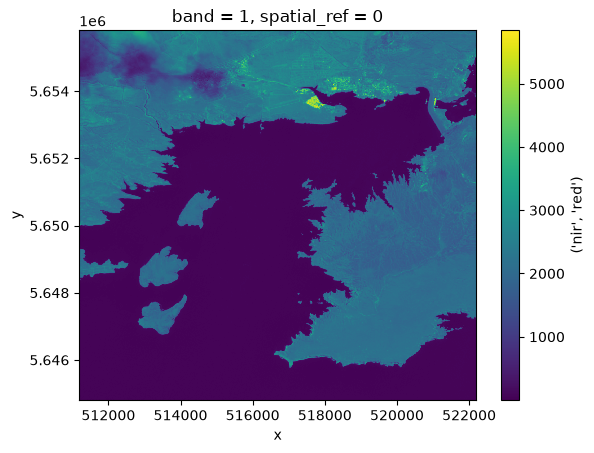

In [11]:
rioxarray.open_rasterio(artifacts_gdf.iloc[4].uri)[0].plot()

## Batch execution with an executor

To run many tasks in parallel, pass the task list to an `Executor`. For COG/I/O-bound extractors like this one, `LocalExecutor(use_threads=True)` is the safer choice in Jupyter and avoids the pickling issues that can make `ProcessPoolExecutor` hang.


In [12]:
from aereo.executors import LocalExecutor

executor = LocalExecutor(workers=4, use_threads=True)
artifacts = executor(tasks)

print(f"\u2713 Extracted {len(artifacts)} artifact row(s) from {len(tasks)} task(s)")
artifacts[["id", "uri", "grid_cell", "start_time"]].head()

/root/repos/aereo/.venv/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


✓ Extracted 41 artifact row(s) from 6 task(s)


,id,uri,grid_cell,start_time
0,439D_593L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_593L,2024-01-02 14:33:47.691
1,439D_592L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_592L,2024-01-02 14:33:47.691
2,439D_591L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,439D_591L,2024-01-02 14:33:47.691
3,438D_594L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_594L,2024-01-02 14:33:47.691
4,438D_593L_nir+red_20240102T143347,/tmp/aereo_extraction/job-sentinel2_sample/loc...,438D_593L,2024-01-02 14:33:47.691


(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


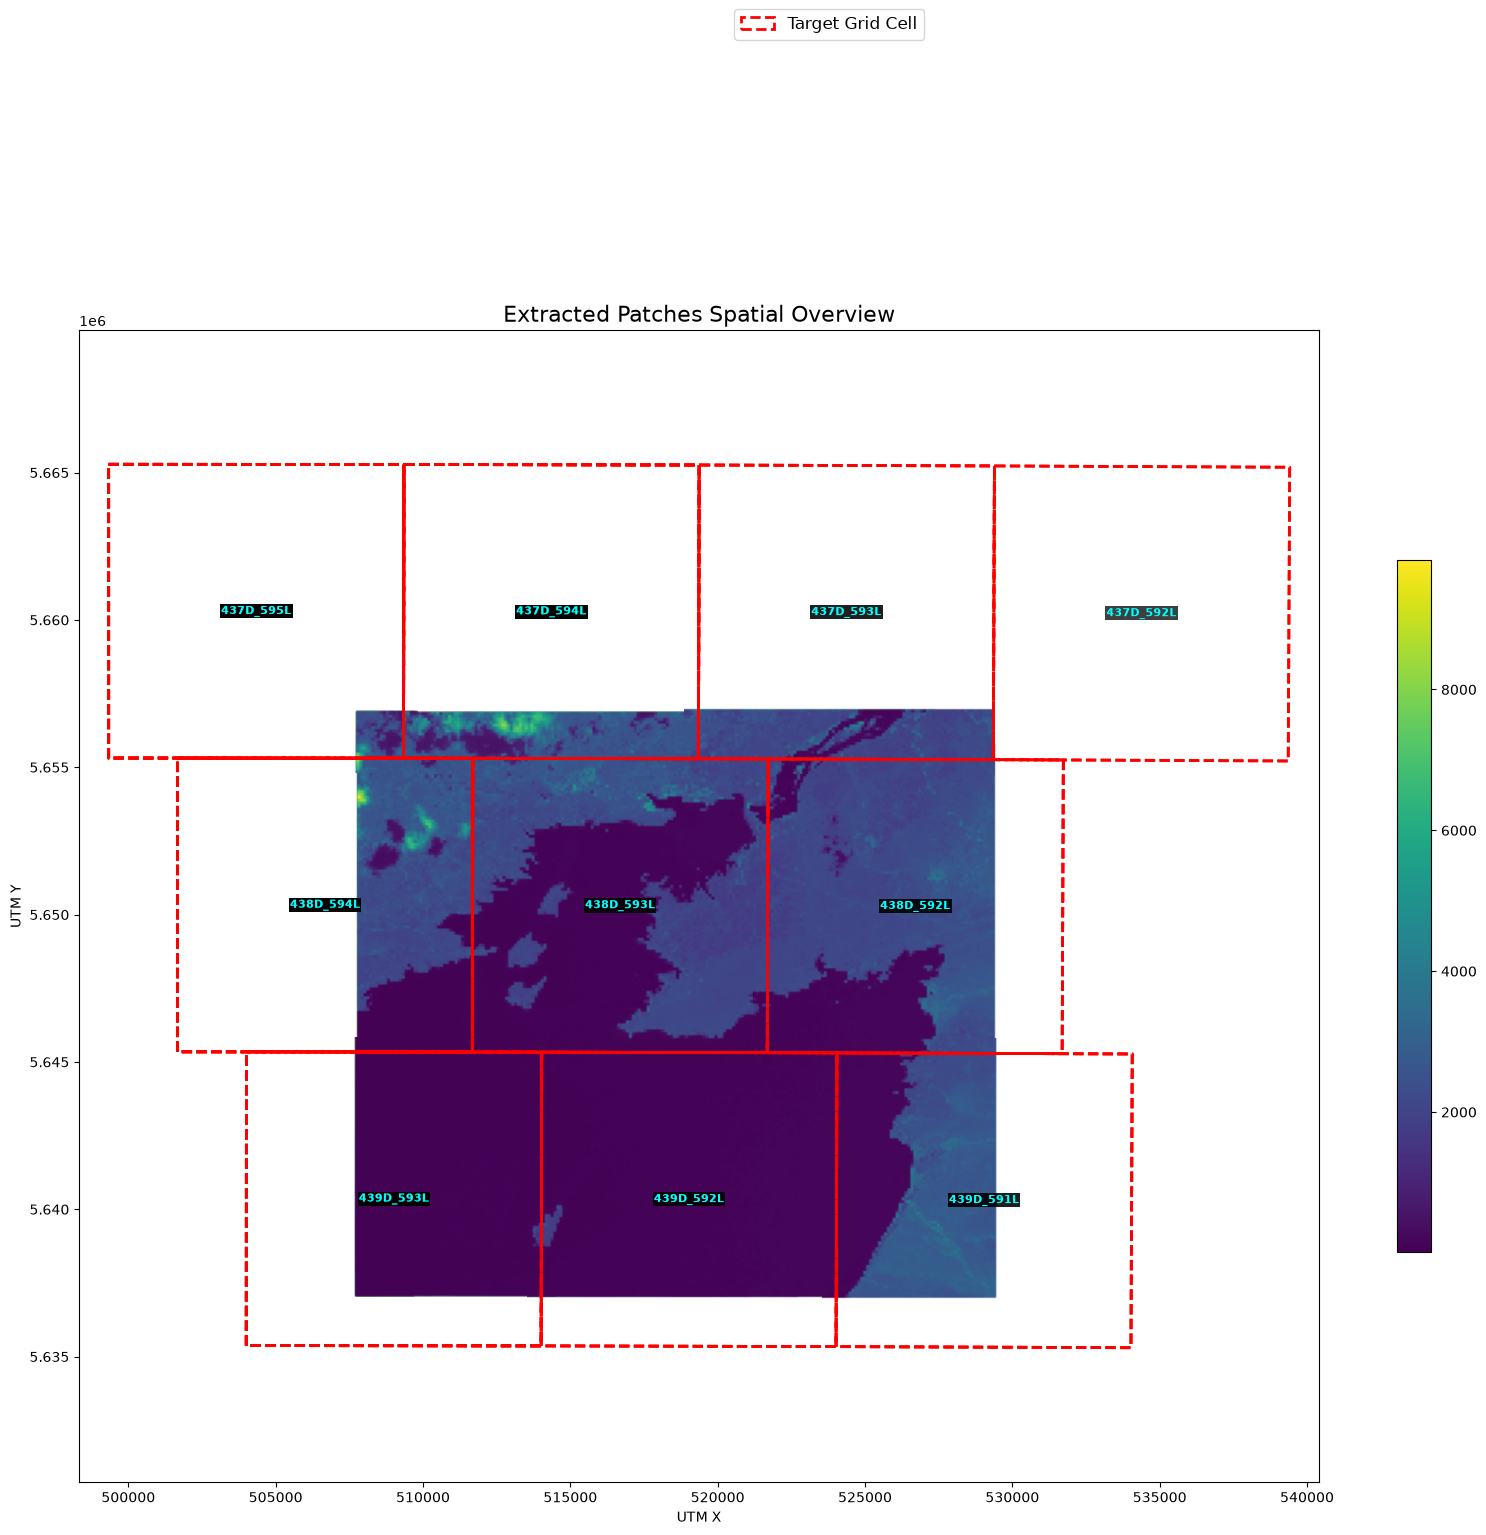

In [13]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, ds_factor=10, cmap="viridis")